## Setup

Set up the working environment:

In [1]:
# Load basic libraries
import os
import sys
from pathlib import Path

# Are we working on google colab?
if 'google.colab' in str(get_ipython()):
    
    from google.colab import drive
    drive.mount('/content/drive')
    
    # If so, look for the files on the drive location
    root_path = Path('content/drive/MyDrive/TFM')
    
else:
    
    # If the session is running local
    root_path = Path(os.path.abspath(".."))
    
    # Add path to Python's system
    if str(root_path) not in sys.path:
        sys.path.append(str(root_path))
    
    # Create file path
    file_path = root_path / 'data' / 'clean' / 'clinical_data.parquet'
    results_path = root_path / 'results' / 'clinical_data_modelling'

Load libraries:

In [2]:
# DATA WRANGLING AND STATISTICS
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# HYPERPARAMETER TUNING
import optuna
from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, FloatDistribution, CategoricalDistribution
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MODEL SELECTION
from sklearn.model_selection import train_test_split, StratifiedKFold

# MODEL TRAINING 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier)
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from src.models.training_and_evaluation import optimize_model_optuna_search, optimize_model_random_search

# MODEL EVALUATION
from src.models.plots import (plot_cm, 
                            plot_overfitting_bars, 
                            plot_combined_pr_curves, 
                            plot_metric_comparison,
                            plot_all_metrics_comparison)
from src.models.results import save_scores, save_pr_curves_long_format, save_model



Ensure reproducibility:

In [3]:
seed = 42

## Data

Load the data and check the structure: and split the data into target class and features:

In [4]:
# Load data
df = pd.read_parquet(file_path)

# Check general structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   gender                      720 non-null    category
 1   age                         720 non-null    float64 
 2   smoking_status              720 non-null    category
 3   code                        720 non-null    float64 
 4   center                      720 non-null    category
 5   intervention                720 non-null    category
 6   BMI                         720 non-null    float64 
 7   MET                         720 non-null    float64 
 8   hypertension                720 non-null    category
 9   type2_diabetes              720 non-null    category
 10  hypercholesterolemia        720 non-null    category
 11  hypolipidemic_medication    703 non-null    category
 12  OSA                         720 non-null    category
 13  stroke              

Separate the features from the target class:

In [5]:
# Features
X = df.drop(["code", "center", "AF_recurrence"], axis=1)

# Target class manually encoded
y = df["AF_recurrence"].map({"no":0, "yes":1})

## Preprocessing

Divide data set into train and test set:

In [6]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed,
    shuffle=True,
    stratify=y,
    )

# Compute the predicted class ratio
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()
ratio = negatives / positives

print(f"Negative cases: {negatives}, Positive cases: {positives}")
print(f"Imbalance ratio suggested: {ratio:.2f}")

Negative cases: 367, Positive cases: 209
Imbalance ratio suggested: 1.76


Create the preprocessing pipeline:

In [7]:
# Divide features by their data type
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(include='category').columns

# Transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('cat', OneHotEncoder(handle_unknown='ignore'))
])

# Join transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Training and optimization

Training each model with stratified 5-fold cross validation and ensuring reproducibility:

In [8]:
my_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

#### Logistic Regression (Elastic Net)

Set up the pipeline and the parameter distributions:

In [9]:
# Full pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(random_state=seed,
                            solver='saga',
                            max_iter=10000))
])

# Parameters grid
params_EN = {
    'clf__l1_ratio': FloatDistribution(0, 1),
    'clf__C': FloatDistribution(1e-4, 1e3, log=True)
    }

Train and optimize the model:

In [ ]:

(optimized_EN, 
train_metrics_mean_EN,
train_metrics_std_EN, 
val_metrics_mean_EN, 
val_metrics_std_EN, 
test_metrics_EN,
precs_EN, recs_EN) = optimize_model_optuna_search(pipe_EN, params_EN, 
                                                X_train, y_train, X_test, y_test, 
                                                cv=my_cv, 
                                                seed=seed)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:76: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Extract hyerparameters and display them to check if the distribution is wide enough:

In [11]:
best_params_EN = save_model(optimized_EN, results_path)

best_params_EN

,Hyperparameter,Optimal Value
1,C,1.374305
2,class_weight,None
3,dual,False
4,fit_intercept,True
5,intercept_scaling,1
6,l1_ratio,0.373519
7,max_iter,10000
8,n_jobs,None
9,penalty,deprecated
10,random_state,42


Check the confusion matrix:

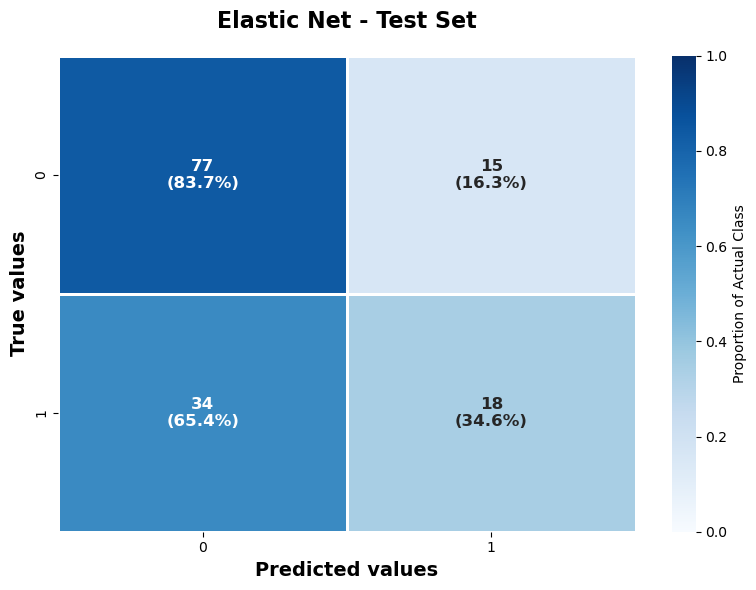

In [12]:
# Compute predictions for the test set
y_pred_EN = optimized_EN.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_EN, 
        title="Elastic Net - Test Set")

Check the overfitting:

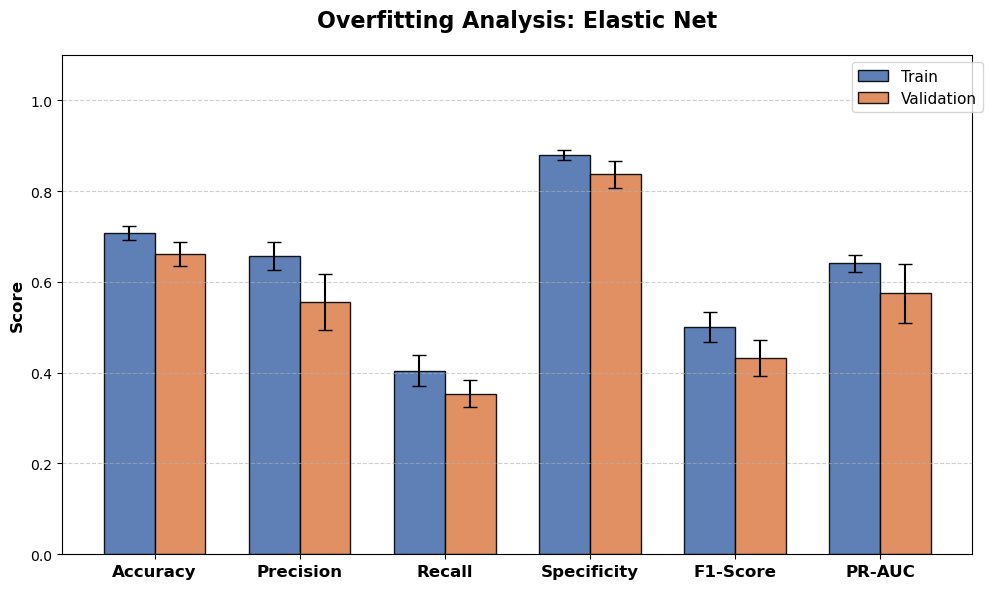

In [13]:
plot_overfitting_bars(train_metrics_mean_EN, val_metrics_mean_EN, 
                    train_metrics_std_EN, val_metrics_std_EN, 
                    model_name="Elastic Net")

### Support Vector Machine


Set up the pipeline and the parameter distributions:

In [14]:
# Full pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', SVC(random_state=seed))
])

# Parameters grid
params_dist_SVM = {
    'clf__C': FloatDistribution(1e-4, 1e3, log=True),
    'clf__kernel': CategoricalDistribution(['linear', 'rbf', 'poly', 'sigmoid']),
    'clf__gamma': CategoricalDistribution(['scale', 'auto']), 
    'clf__degree': IntDistribution(2, 5),
    'clf__class_weight': CategoricalDistribution([None, 'balanced'])
}

# PROBAR BÚSQUEDA ALEATORIA PARA COMPROBAR SI HAY UN MÍNIMO LOCAL EN LA SEMILLA 42 AL USAR OPTUNA
# params_dist_SVM = {
#     'clf__C': uniform(0.1, 10),
#     'clf__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  
#     'clf__gamma': ['scale', 'auto'],
#     'clf__degree': [2, 3, 4, 5]
# }

Train and optimize the model:

In [15]:
(optimized_SVM, 
train_metrics_mean_SVM,
train_metrics_std_SVM, 
val_metrics_mean_SVM, 
val_metrics_std_SVM, 
test_metrics_SVM,
precs_SVM, recs_SVM) = optimize_model_optuna_search(pipe_SVM, params_dist_SVM, 
                                    X_train, y_train, X_test, y_test, 
                                    cv=my_cv)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:76: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [16]:
best_params_SVM = save_model(optimized_SVM, results_path)

best_params_SVM

,Hyperparameter,Optimal Value
1,C,5.532871
2,break_ties,False
3,cache_size,200
4,class_weight,None
5,coef0,0.0
6,decision_function_shape,ovr
7,degree,3
8,gamma,auto
9,kernel,sigmoid
10,max_iter,-1


Check the confusion matrix:

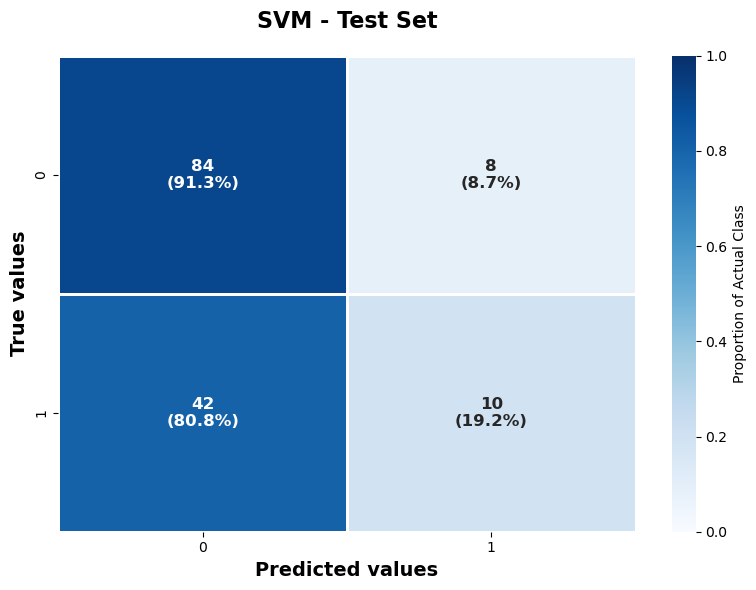

In [17]:
# Compute predictions for the test set
y_pred_SVM = optimized_SVM.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_SVM, 
        title="SVM - Test Set")

Check the overfitting:

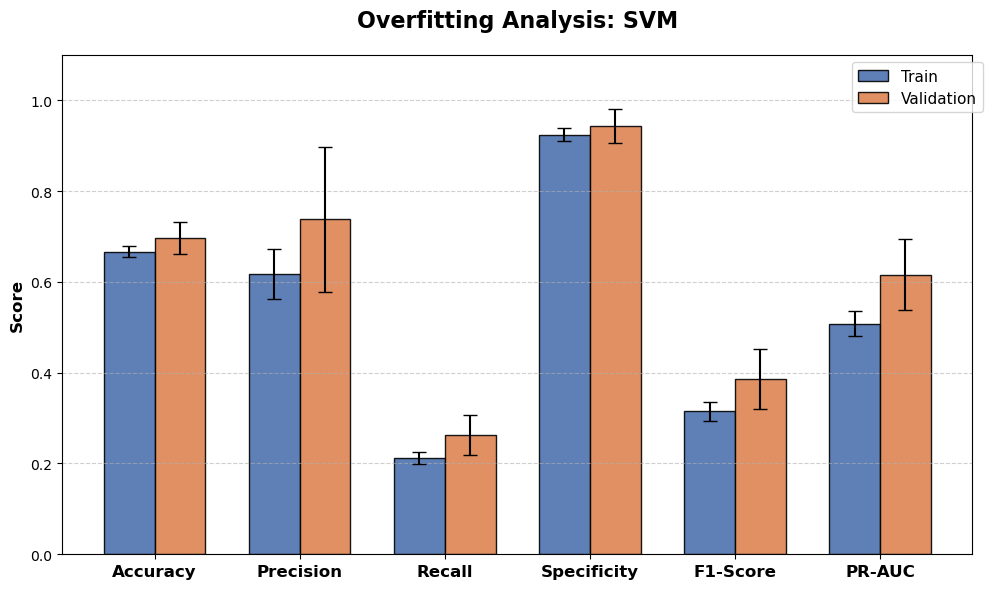

In [18]:
plot_overfitting_bars(train_metrics_mean_SVM, val_metrics_mean_SVM, 
                    train_metrics_std_SVM, val_metrics_std_SVM, 
                    model_name="SVM")

### K-Nearest Neighbors

Set up the pipeline and the parameters distributions:

In [19]:
# Full pipeline
pipe_KNN = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier())
])

# Parameters grid
params_dist_KNN = {
    'clf__n_neighbors': IntDistribution(3, 50),
    'clf__weights': CategoricalDistribution(['uniform', 'distance']),
    'clf__p': IntDistribution(1, 2),
    'clf__algorithm': CategoricalDistribution(['auto', 'ball_tree', 'kd_tree', 'brute'])
}

Train and optimize the model:

In [20]:
(optimized_KNN, 
train_metrics_mean_KNN,
train_metrics_std_KNN, 
val_metrics_mean_KNN, 
val_metrics_std_KNN, 
test_metrics_KNN,
precs_KNN, recs_KNN) = optimize_model_optuna_search(pipe_KNN, params_dist_KNN, 
                                                    X_train, y_train, X_test, y_test, 
                                                    cv=my_cv)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:76: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
c:\Users\Miguel\miniconda3\envs\tfm\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [21]:
best_params_KNN = save_model(optimized_KNN, results_path)

best_params_KNN

,Hyperparameter,Optimal Value
1,algorithm,kd_tree
2,leaf_size,30
3,metric,minkowski
4,metric_params,None
5,n_jobs,None
6,n_neighbors,44
7,p,1
8,weights,uniform


Check the confusion matrix:

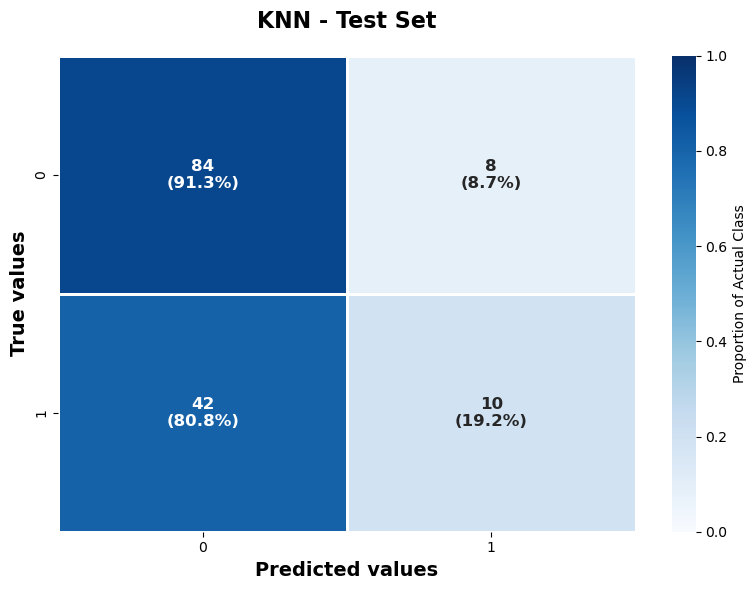

In [22]:
# Compute predictions for the test set
y_pred_SVM = optimized_SVM.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_SVM, 
        title="KNN - Test Set")

Check the overfitting:

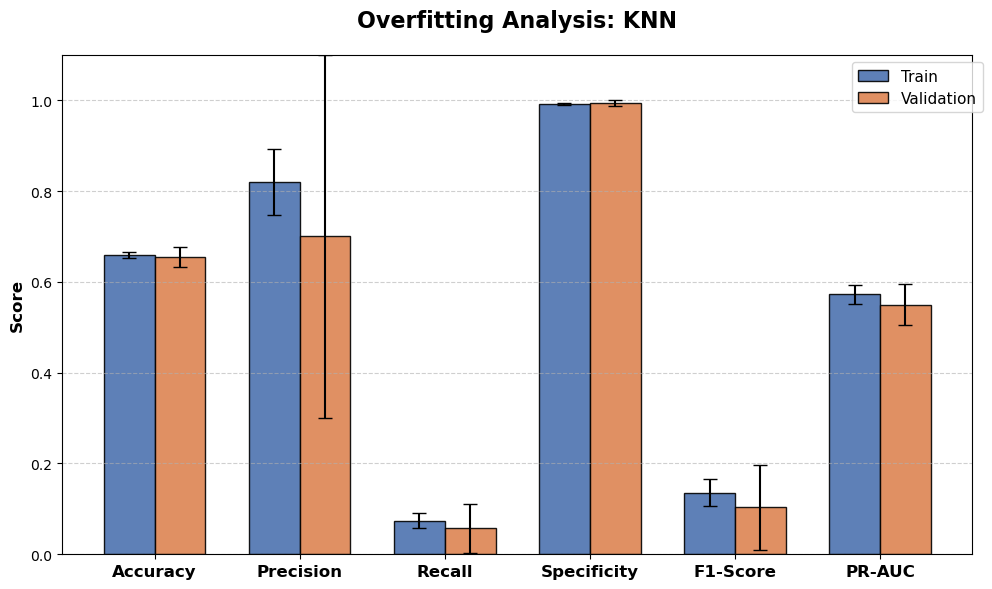

In [23]:
plot_overfitting_bars(train_metrics_mean_KNN, val_metrics_mean_KNN, 
                    train_metrics_std_KNN, val_metrics_std_KNN, 
                    model_name="KNN")

### Random Forest

Set up the pipeline and the parameters distributions:

In [24]:
# Full pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_RF = {
    'clf__n_estimators': IntDistribution(50, 300),
    'clf__max_depth': IntDistribution(2, 32),
    'clf__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'clf__min_samples_split': IntDistribution(2, 20),
    'clf__criterion': CategoricalDistribution(['gini', 'entropy']),
    'clf__class_weight': CategoricalDistribution([None, 'balanced', 'balanced_subsample'])
}

Train and optimize the model:

In [25]:
(optimized_RF, 
train_metrics_mean_RF,
train_metrics_std_RF, 
val_metrics_mean_RF, 
val_metrics_std_RF, 
test_metrics_RF,
precs_RF, recs_RF) = optimize_model_optuna_search(pipe_RF, params_dist_RF, 
                                                X_train, y_train, X_test, y_test, 
                                                cv=my_cv)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:76: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [26]:
best_params_RF = save_model(optimized_RF, results_path)

best_params_RF

,Hyperparameter,Optimal Value
1,bootstrap,True
2,ccp_alpha,0.0
3,class_weight,None
4,criterion,gini
5,max_depth,3
6,max_features,sqrt
7,max_leaf_nodes,None
8,max_samples,None
9,min_impurity_decrease,0.0
10,min_samples_leaf,1


Check the confusion matrix:

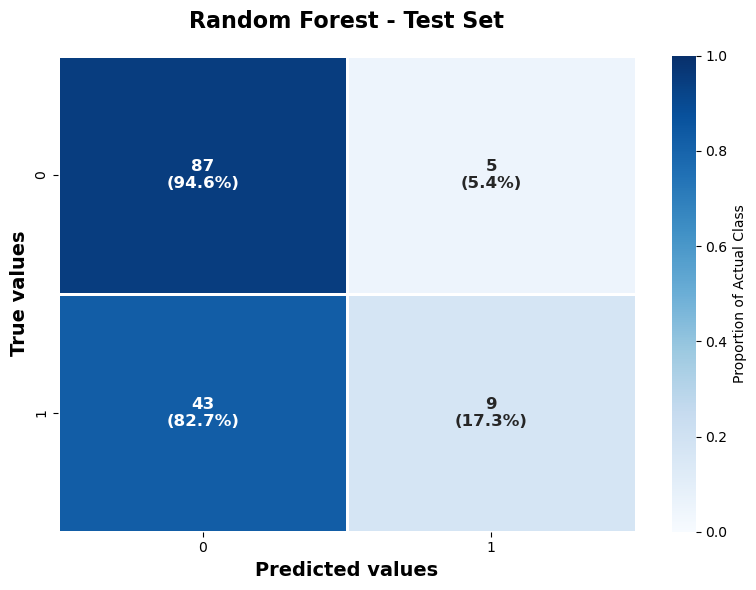

In [27]:
# Compute predictions for the test set
y_pred_RF = optimized_RF.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_RF, 
        title="Random Forest - Test Set")

Check the overfitting:

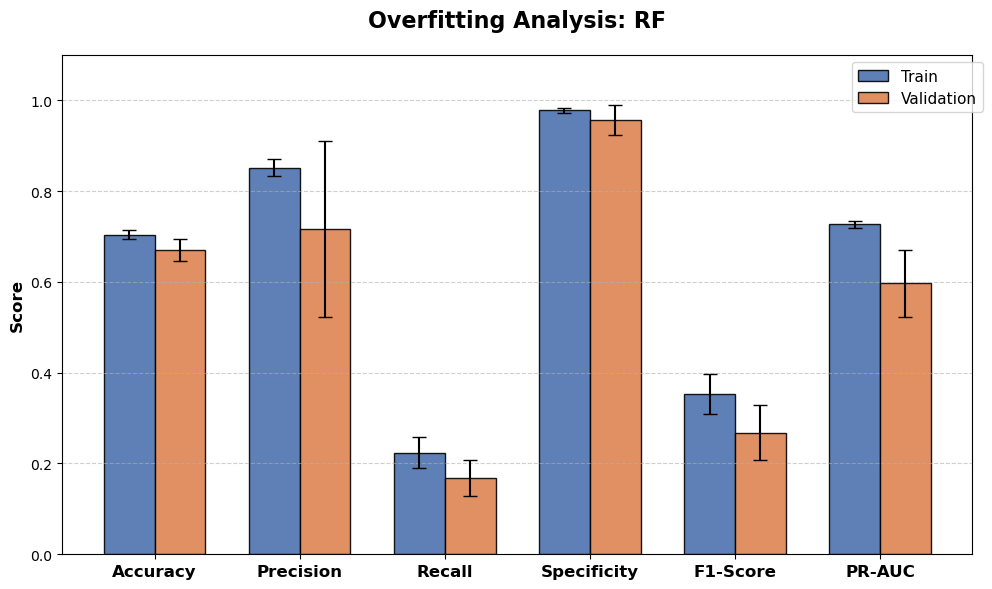

In [28]:
plot_overfitting_bars(train_metrics_mean_RF, val_metrics_mean_RF, 
                    train_metrics_std_RF, val_metrics_std_RF, 
                    model_name="RF")

### Extremely Randomized Trees

Set up the pipeline and the parameters distributions:

In [29]:
# Full pipeline
pipe_ET = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', ExtraTreesClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_ET = {
    'clf__n_estimators': IntDistribution(50, 300),
    'clf__max_depth': IntDistribution(2, 32),
    'clf__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'clf__min_samples_split': IntDistribution(2, 20),
    'clf__criterion': CategoricalDistribution(['gini', 'entropy']),
    'clf__class_weight': CategoricalDistribution([None, 'balanced', 'balanced_subsample'])
}

Train and optimize the model:

In [30]:
(optimized_ET, 
train_metrics_mean_ET,
train_metrics_std_ET, 
val_metrics_mean_ET, 
val_metrics_std_ET, 
test_metrics_ET,
precs_ET, recs_ET) = optimize_model_optuna_search(pipe_ET, params_dist_ET, 
                                                X_train, y_train, X_test, y_test, 
                                                cv=my_cv)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:76: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [31]:
best_params_ET = save_model(optimized_ET, results_path)

best_params_ET

,Hyperparameter,Optimal Value
1,bootstrap,False
2,ccp_alpha,0.0
3,class_weight,None
4,criterion,gini
5,max_depth,6
6,max_features,sqrt
7,max_leaf_nodes,None
8,max_samples,None
9,min_impurity_decrease,0.0
10,min_samples_leaf,1


Check the confusion matrix:

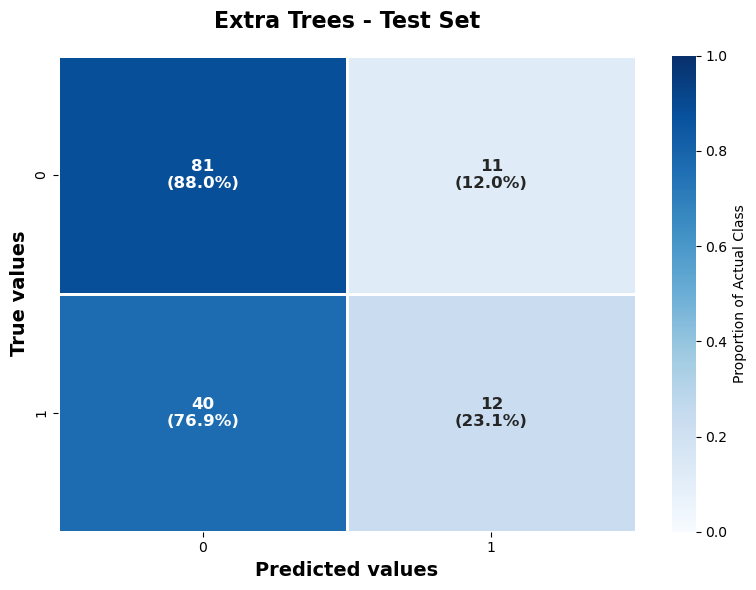

In [32]:
# Compute predictions for the test set
y_pred_ET = optimized_ET.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_ET, 
        title="Extra Trees - Test Set")

Check the overfitting:

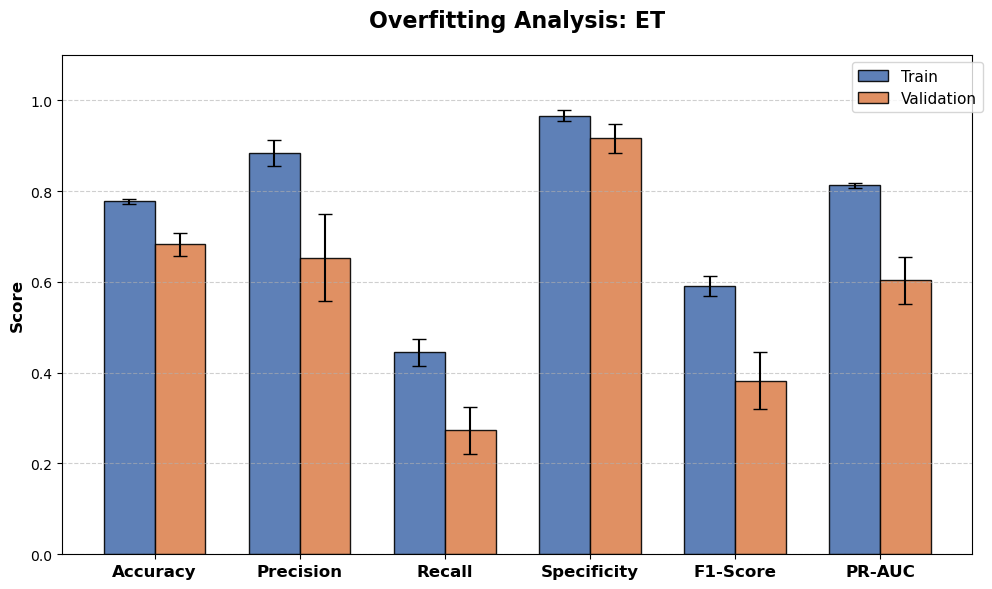

In [33]:
plot_overfitting_bars(train_metrics_mean_ET, val_metrics_mean_ET, 
                    train_metrics_std_ET, val_metrics_std_ET, 
                    model_name="ET")

### Adaptative Boosting

Set up the pipeline and the parameters distributions:

In [34]:
# Full pipeline
pipe_AB = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', AdaBoostClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_AB = {
    'clf__n_estimators': IntDistribution(20, 300),
    'clf__learning_rate': FloatDistribution(0.01, 10)
}

Train and optimize the model:

In [35]:
(optimized_AB, 
train_metrics_mean_AB,
train_metrics_std_AB, 
val_metrics_mean_AB, 
val_metrics_std_AB, 
test_metrics_AB,
precs_AB, recs_AB) = optimize_model_optuna_search(pipe_AB, params_dist_AB,
                                                X_train, y_train, X_test, y_test,
                                                cv=my_cv,
                                                seed=seed)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:76: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [36]:
best_params_AB = save_model(optimized_AB, results_path)

best_params_AB

,Hyperparameter,Optimal Value
1,estimator,NaN
2,learning_rate,0.054157
3,n_estimators,223.000000
4,random_state,42.000000


Check the confusion matrix:

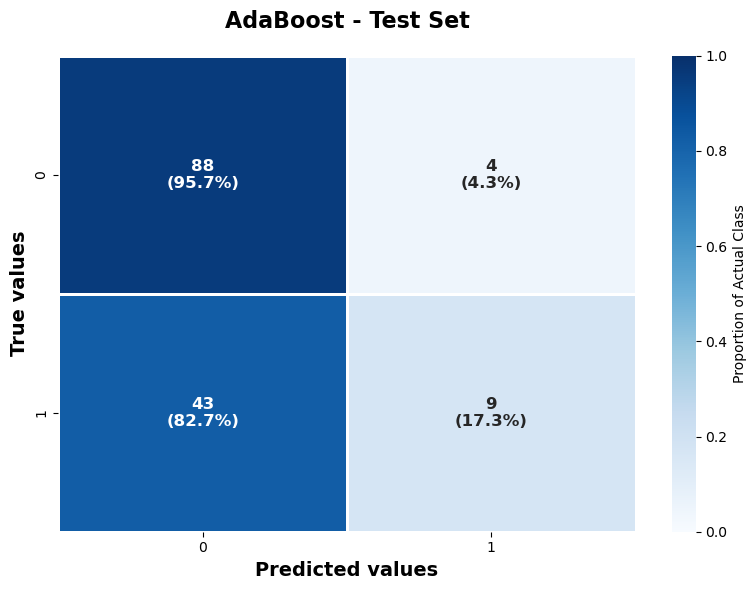

In [37]:
# Compute predictions for the test set
y_pred_AB = optimized_AB.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_AB, 
        title="AdaBoost - Test Set")

Check the overfitting:

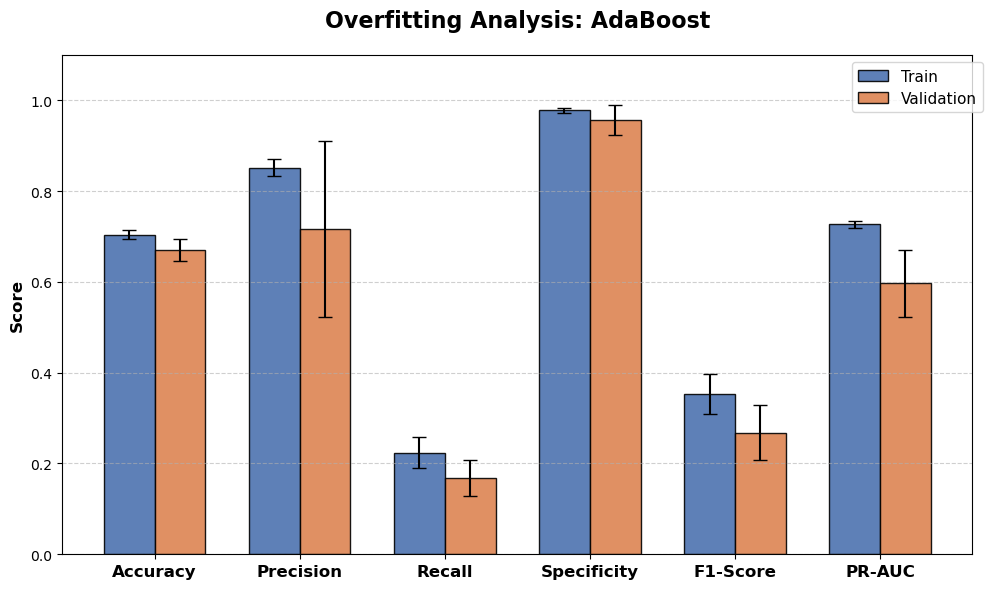

In [38]:
plot_overfitting_bars(train_metrics_mean_RF, val_metrics_mean_RF, 
                    train_metrics_std_RF, val_metrics_std_RF, 
                    model_name="AdaBoost")

### Extreme Gradient Boosting

Set up the pipeline and the parameters distributions:

In [39]:
# Full pipeline
pipe_XGB = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(random_state=seed,
                        scale_pos_weight=ratio, 
                        eval_metric='logloss'))
])

# Hyperparameters search space
params_dist_XGB = {
    'clf__n_estimators': IntDistribution(20, 400),
    'clf__max_depth': IntDistribution(3, 10),
    'clf__learning_rate': FloatDistribution(0.01, 0.3),
    
    'clf__subsample': FloatDistribution(0.4, 0.6),
    'clf__colsample_bytree': FloatDistribution(0.4, 0.6),
    
    # Regularization parameters:
    'clf__reg_alpha': FloatDistribution(0, 10),
    'clf__reg_lambda': FloatDistribution(1, 10)
}

Train and optimize the model:

In [40]:
(optimized_XGB, 
train_metrics_mean_XGB,
train_metrics_std_XGB, 
val_metrics_mean_XGB, 
val_metrics_std_XGB, 
test_metrics_XGB,
precs_XGB, recs_XGB) = optimize_model_optuna_search(pipe_XGB, params_dist_XGB,
                                                X_train, y_train, X_test, y_test, 
                                                cv=my_cv,
                                                seed=seed)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:76: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [41]:
best_params_XGB = save_model(optimized_XGB, results_path)

best_params_XGB

,Hyperparameter,Optimal Value
1,objective,binary:logistic
2,base_score,None
3,booster,None
4,callbacks,None
5,colsample_bylevel,None
6,colsample_bynode,None
7,colsample_bytree,0.536473
8,device,None
9,early_stopping_rounds,None
10,enable_categorical,False


Check the confusion matrix:

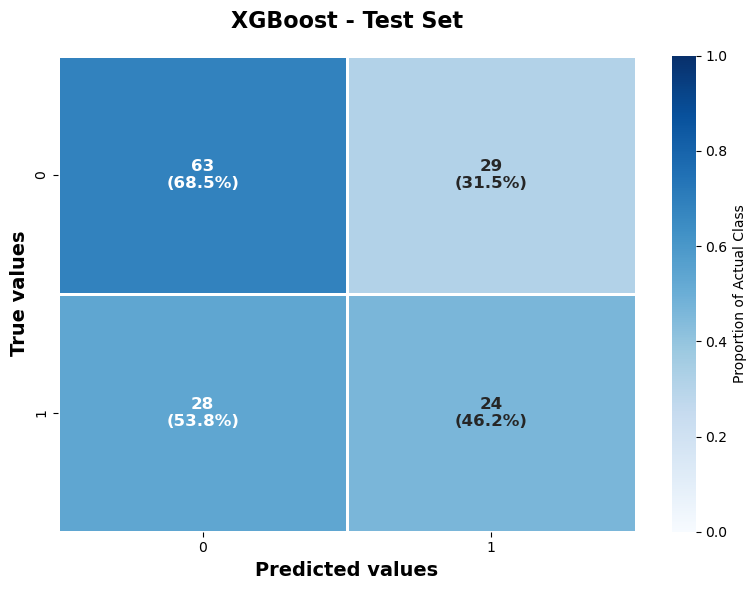

In [42]:
# Compute predictions for the test set
y_pred_XGB = optimized_XGB.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_XGB, 
        title="XGBoost - Test Set")

Check the overfitting:

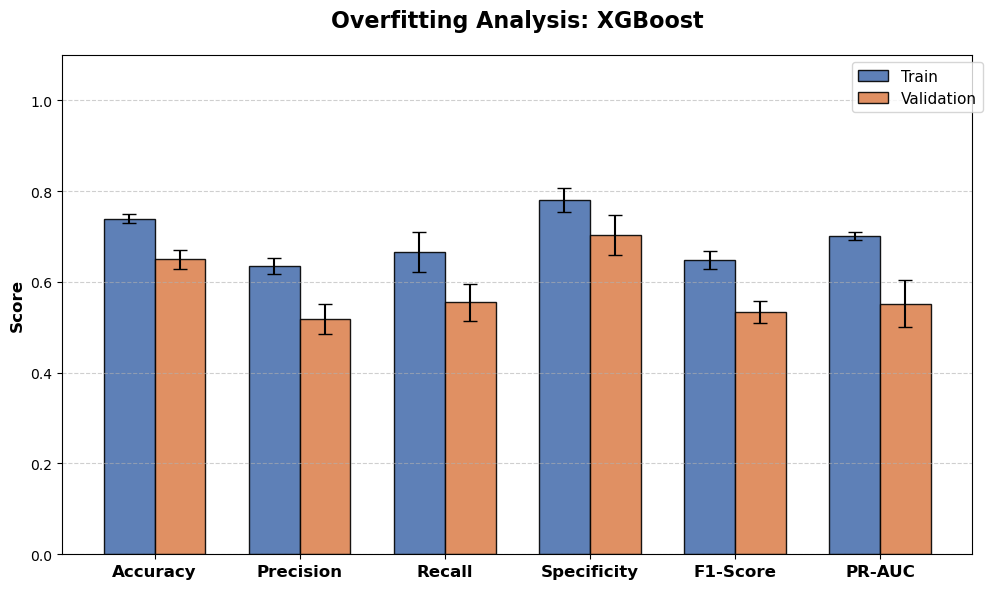

In [43]:
plot_overfitting_bars(train_metrics_mean_XGB, val_metrics_mean_XGB, 
                    train_metrics_std_XGB, val_metrics_std_XGB, 
                    model_name="XGBoost")

### Multilayer Perceptron

Set up the pipeline and the parameters distributions:

Train and optimize the model:

Check the confusion matrix:

Check the overfitting:

## Comparison between models

### Individual scores

Join the basic metrics into a data frame where each column is a different metric and each row a different model. Mean scores:

In [44]:
# Get the model's names into a list
models = ['Elastic Net', 
        'SVM', 
        'KNN', 
        'Random Forest', 
        'Extra Trees', 
        'AdaBoost', 
        'XGBoost']

# Save the mean metrics of different models into a csv
train_metrics_mean=[train_metrics_mean_EN, train_metrics_mean_SVM, train_metrics_mean_KNN, train_metrics_mean_RF, train_metrics_mean_ET, train_metrics_mean_AB, train_metrics_mean_XGB]
validation_metrics_mean=[val_metrics_mean_EN, val_metrics_mean_SVM, val_metrics_mean_KNN, val_metrics_mean_RF, val_metrics_mean_ET, val_metrics_mean_AB, val_metrics_mean_XGB]
test_metrics_mean=[test_metrics_EN, test_metrics_SVM, test_metrics_KNN, test_metrics_RF, test_metrics_ET, test_metrics_AB, test_metrics_XGB]

(test_results, 
mean_train_results, 
mean_val_results) = save_scores(models, test_metrics=test_metrics_mean, 
                        train_metrics=train_metrics_mean,
                        validation_metrics=validation_metrics_mean,
                        results_path=results_path,
                        prefix="mean")


Standard deviations associated to each mean score:

In [45]:
# Save the metrics' std of different models into a csv
train_metrics_std=[train_metrics_std_EN, train_metrics_std_SVM, train_metrics_std_KNN, train_metrics_std_RF, train_metrics_std_ET, train_metrics_std_AB, train_metrics_std_XGB]
validation_metrics_std=[val_metrics_std_EN, val_metrics_std_SVM, val_metrics_std_KNN, val_metrics_std_RF, val_metrics_std_ET, val_metrics_std_AB, val_metrics_std_XGB]
test_metrics_std=[None for model in models]

(_, 
std_train_results, 
std_val_results) = save_scores(models, 
                        test_metrics=test_metrics_std,
                        train_metrics=train_metrics_std,
                        validation_metrics=validation_metrics_std,
                        results_path=results_path,
                        prefix="std")

Draw barplots to compare different models:

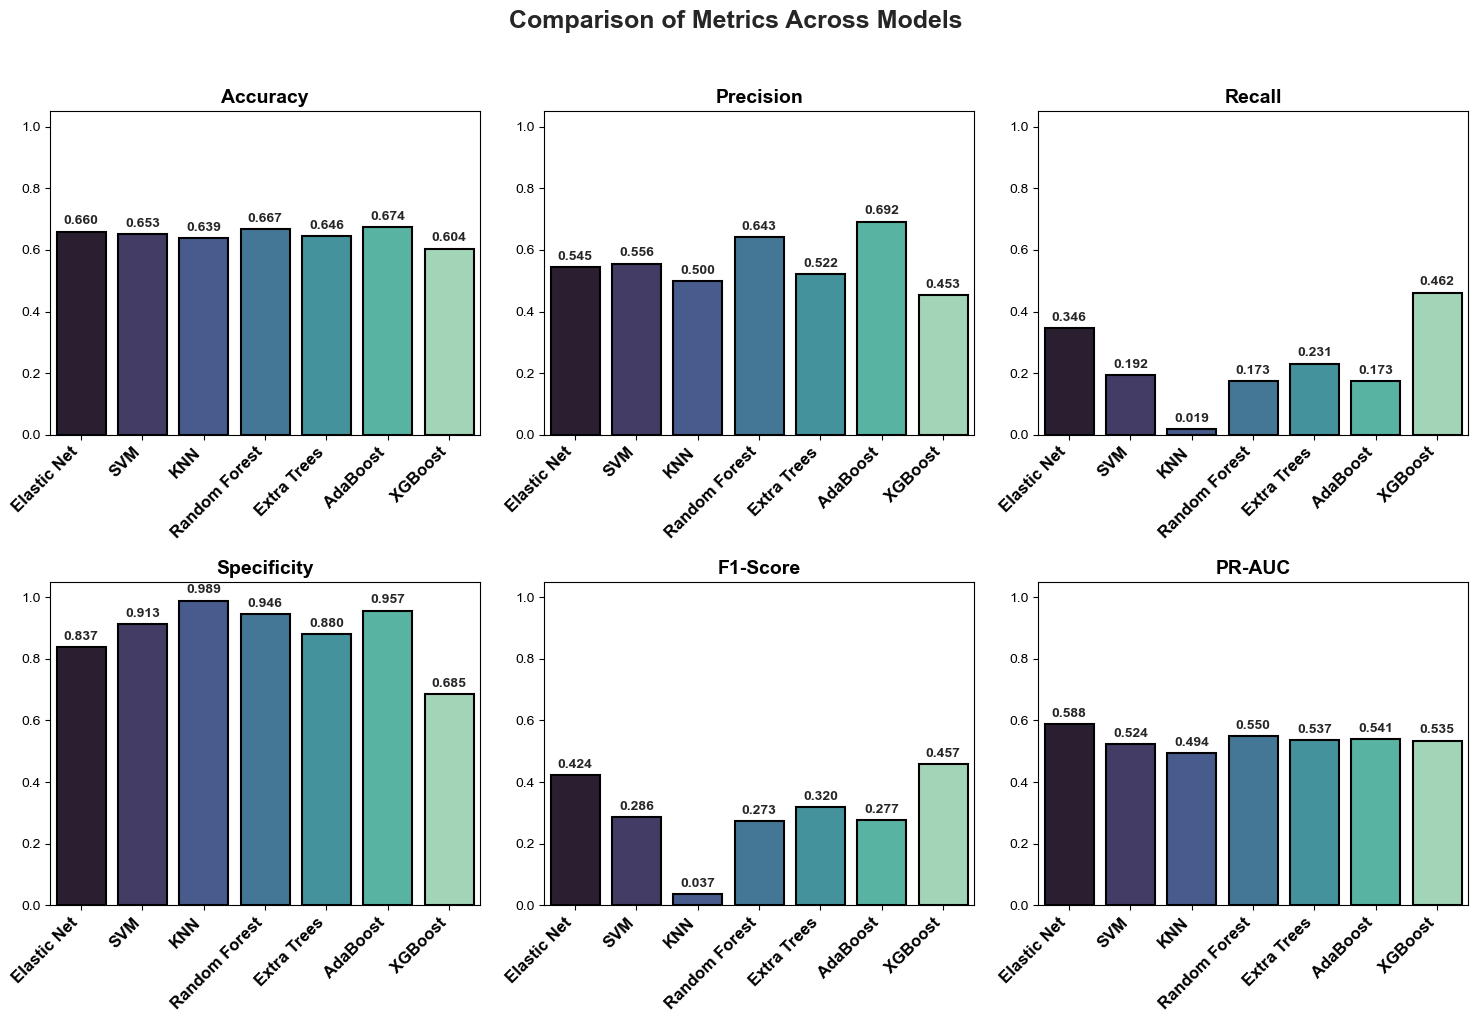

In [46]:
plot_all_metrics_comparison(test_results, color_palette='mako')

### Precision-Recall curves

Join the curves metrics (precision and recall scores at different thresholds):

In [47]:
# Save the precision and recall values for the PR curves into a csv
precs = [precs_EN, precs_SVM, precs_KNN, precs_RF, precs_ET, precs_AB, precs_XGB]
recs = [recs_EN, recs_SVM, recs_KNN, recs_RF, recs_ET, recs_AB, recs_XGB]

pr_results = save_pr_curves_long_format(models, precs, recs, 
                                        results_path=results_path, 
                                        prefix="pr_curves")

Plot the precision-recall curves:

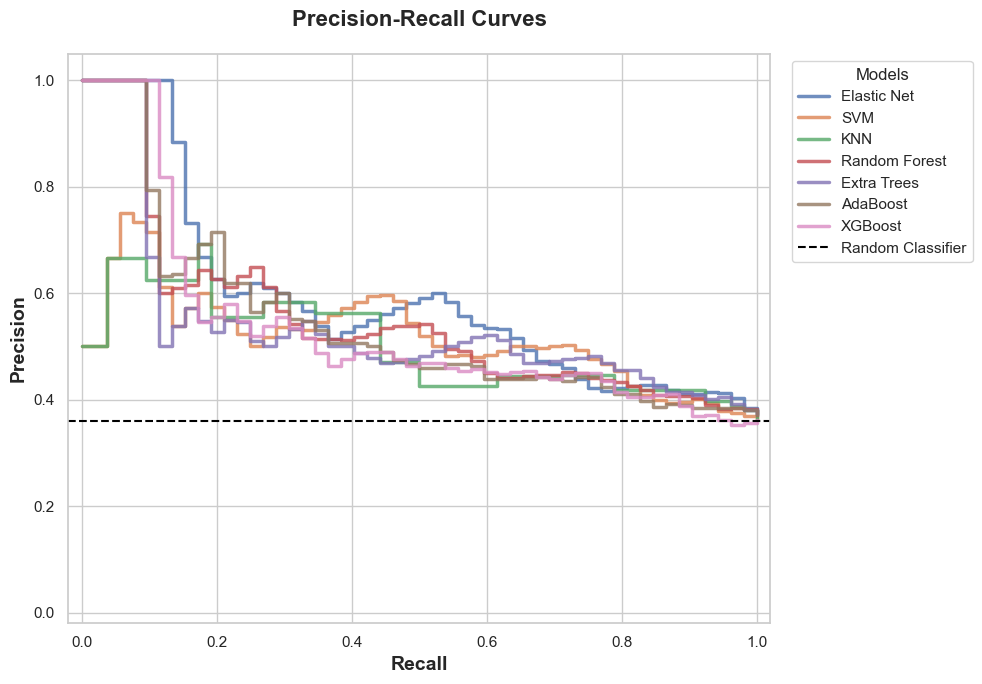

In [48]:
plot_combined_pr_curves(pr_results)